# Notebook 02 — Pré-processamento

**Objetivo:** preparar os dados para treinamento.

**Etapas:**
1. Carregamento do dataset bruto.
2. Limpeza: remoção de duplicatas, tratamento de valores faltantes.
3. Codificação de rótulos (`LabelEncoder`).
4. Normalização de features (`StandardScaler`).
5. Divisão estratificada 70/15/15.
6. Persistência dos splits em `dataset/processed/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import (
    ACTION_CLASSES,
    FEATURE_COLUMNS,
    PROCESSED_DIR,
    RANDOM_SEED,
    RAW_DATASET_FILE,
)
from src.dataset.preprocessing import (
    handle_missing_values,
    remove_duplicates,
)
from src.dataset.split import load_and_split

print(f"[INFO] Carregando {RAW_DATASET_FILE}")
df = pd.read_csv(RAW_DATASET_FILE)
print(f"Shape inicial: {df.shape}")

[INFO] Carregando /Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/dataset/raw/accessibility_dataset.csv
Shape inicial: (20000, 15)


In [2]:
# =====================================================================
# 1. Limpeza
# =====================================================================
df_clean = remove_duplicates(df)
df_clean = handle_missing_values(df_clean)
print(f"Shape após limpeza: {df_clean.shape}")
print(f"Sem valores faltantes: {not df_clean.isna().any().any()}")

[INFO] 17636 duplicatas removidas.
Shape após limpeza: (2364, 15)
Sem valores faltantes: True


In [3]:
# =====================================================================
# 2. Divisão 70/15/15
# =====================================================================
train_df, val_df, test_df = load_and_split(df_clean, seed=RANDOM_SEED)

print(f"\nTreino:      {len(train_df):>5} amostras ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"Validação:   {len(val_df):>5} amostras ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"Teste:       {len(test_df):>5} amostras ({len(test_df)/len(df_clean)*100:.1f}%)")

[INFO] Split: train=1654 | val=355 | test=355
[INFO] Splits salvos em /Users/elpidio.junior/Documents/_projetos/accessibility-dl-moodle/dataset/processed

Treino:       1654 amostras (70.0%)
Validação:     355 amostras (15.0%)
Teste:         355 amostras (15.0%)


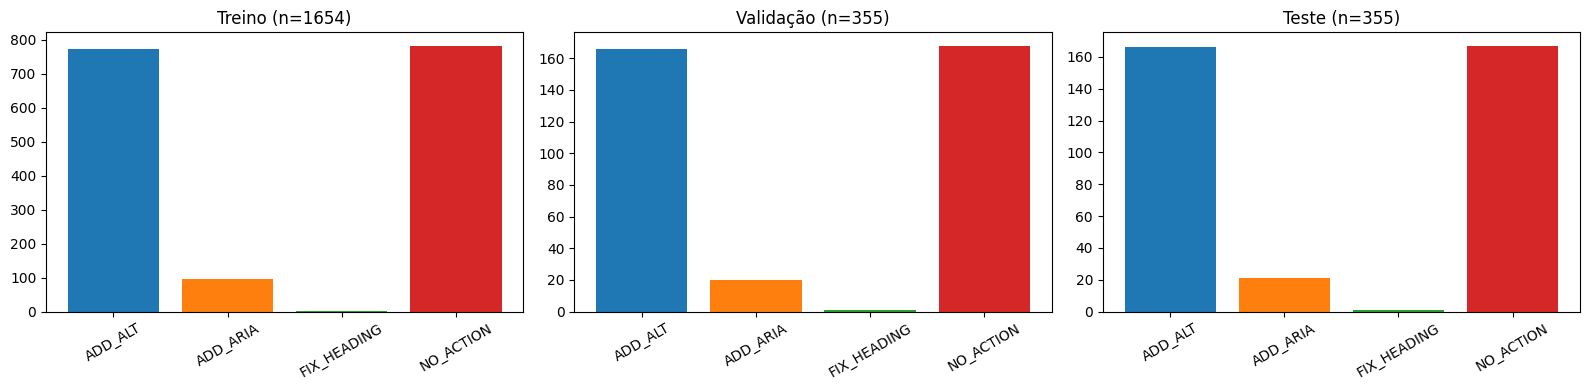


Conclusão: a estratificação preserva o balanceamento em todos os splits.


In [4]:
# =====================================================================
# 3. Verificação de balanceamento nos splits
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (name, data) in enumerate([("Treino", train_df), ("Validação", val_df), ("Teste", test_df)]):
    counts = data["action"].value_counts().sort_index()
    axes[i].bar(counts.index, counts.values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][: len(counts)])
    axes[i].set_title(f"{name} (n={len(data)})")
    axes[i].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

print("\nConclusão: a estratificação preserva o balanceamento em todos os splits.")

In [5]:
import matplotlib.pyplot as plt

In [6]:
# =====================================================================
# 4. Normalização (StandardScaler)
# =====================================================================
from src.dataset.preprocessing import normalize_features

X_train = train_df[FEATURE_COLUMNS].astype(int)
X_train_scaled, scaler = normalize_features(X_train, fit=True)

print("Estatísticas após normalização (treino):")
print(f"  Média por feature: {X_train_scaled.mean(axis=0).round(2)}")
print(f"  Desvio por feature: {X_train_scaled.std(axis=0).round(2)}")

Estatísticas após normalização (treino):
  Média por feature: [-0. -0.  0. -0. -0. -0.  0. -0. -0.  0. -0.]
  Desvio por feature: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
# =====================================================================
# 5. Codificação de rótulos (LabelEncoder)
# =====================================================================
from src.dataset.preprocessing import encode_labels

y_train, le = encode_labels(train_df["action"])
print(f"Classes (ordem fixa): {le.classes_.tolist()}")
print(f"Primeiros 5 rótulos codificados: {y_train[:5]}")

Classes (ordem fixa): ['ADD_ALT', 'ADD_ARIA', 'FIX_HEADING', 'NO_ACTION']
Primeiros 5 rótulos codificados: [3 0 3 0 0]


In [8]:
# =====================================================================
# 6. Verificação dos arquivos salvos
# =====================================================================
from src.config import TRAIN_FILE, VAL_FILE, TEST_FILE

for path, name in [(TRAIN_FILE, "treino"), (VAL_FILE, "validação"), (TEST_FILE, "teste")]:
    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f"  ✓ {name:<12} {path.name:<20} {size_kb:>6.1f} KB")
    else:
        print(f"  ✗ {name:<12} {path.name:<20} (não encontrado)")

  ✓ treino       train.csv             167.7 KB
  ✓ validação    validation.csv         36.6 KB
  ✓ teste        test.csv               36.7 KB


# Conclusões

1. O dataset está **limpo** (sem duplicatas, sem valores faltantes).
2. Os splits estão **estratificados** e **reproduzíveis** (seed=42).
3. As features foram **normalizadas** com `StandardScaler` (média 0, desvio 1).
4. As classes foram **codificadas** com `LabelEncoder` em ordem fixa: `ADD_ALT, ADD_ARIA, FIX_HEADING, NO_ACTION`.
5. Os arquivos foram persistidos em `dataset/processed/`.

**Próximo passo:** treinar os modelos (notebooks 03 e 04).